# Task 7 — XGBoost KPI Forecaster

Evaluates the 63 regression models (3 slices × 7 KPIs × 3 horizons) trained to predict future KPI values at 15 / 30 / 60-minute horizons.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.forecaster import (
    load_forecaster, _prepare_fcst_X_y, evaluate_forecaster,
    KPI_COLS, HORIZON_STEPS,
)
from src.features.engineering import build_features
from src.data.splitter import temporal_split

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (14, 4)})


## 1. Load data and build feature matrices

In [2]:
RAW = Path("../data/raw/generated")
slices_raw = {
    "eMBB":  pd.read_parquet(RAW / "embb_synthetic.parquet"),
    "URLLC": pd.read_parquet(RAW / "urllc_synthetic.parquet"),
    "mMTC":  pd.read_parquet(RAW / "mmtc_synthetic.parquet"),
}
test_splits = {}
for stype, df_raw in slices_raw.items():
    others = {k:v for k,v in slices_raw.items() if k!=stype}
    df_feat = build_features(df_raw, stype, others)
    _, _, test_df = temporal_split(df_feat)
    test_splits[stype] = test_df
    print(f"{stype}: {len(test_df):,} test rows")


eMBB: 4,320 test rows
URLLC: 4,320 test rows
mMTC: 4,320 test rows


## 2. MAE / RMSE / MAPE summary table

In [3]:
rows = []
for stype in ["eMBB", "URLLC", "mMTC"]:
    kpis = [k for k in KPI_COLS if k in test_splits[stype].columns]
    for kpi in kpis:
        for h_min, h_steps in HORIZON_STEPS.items():
            model = load_forecaster(stype, kpi, h_min, models_dir=Path("../models"))
            X_test, y_test = _prepare_fcst_X_y(test_splits[stype], kpi, h_steps)
            m = evaluate_forecaster(model, X_test, y_test)
            rows.append({"Slice": stype, "KPI": kpi, "Horizon": f"{h_min}min",
                         "MAE": m["mae"], "RMSE": m["rmse"], "MAPE(%)": m["mape"]})

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))


Slice           KPI Horizon       MAE      RMSE  MAPE(%)
 eMBB dl_throughput   15min   11.0462   19.2035    32.31
 eMBB dl_throughput   30min   15.7845   23.3484    27.45
 eMBB dl_throughput   60min   21.1449   28.2729    46.57
 eMBB       latency   15min    1.7973    3.2184    17.41
 eMBB       latency   30min    2.5922    3.9254    26.04
 eMBB       latency   60min    3.5116    4.7572    36.23
 eMBB        jitter   15min    0.2112    0.3734    20.13
 eMBB        jitter   30min    0.3041    0.4563    29.61
 eMBB        jitter   60min    0.4253    0.5615    43.06
 eMBB   packet_loss   15min    0.0519    0.0907    55.51
 eMBB   packet_loss   30min    0.0744    0.1106    82.69
 eMBB   packet_loss   60min    0.1016    0.1353   127.61
 eMBB      prb_util   15min    0.0364    0.0643    28.81
 eMBB      prb_util   30min    0.0529    0.0791    43.25
 eMBB      prb_util   60min    0.0725    0.0967    62.46
 eMBB  active_users   15min    7.4123   12.9163    22.86
 eMBB  active_users   30min   1

## 3. Actual vs Predicted — eMBB dl_throughput (all horizons)

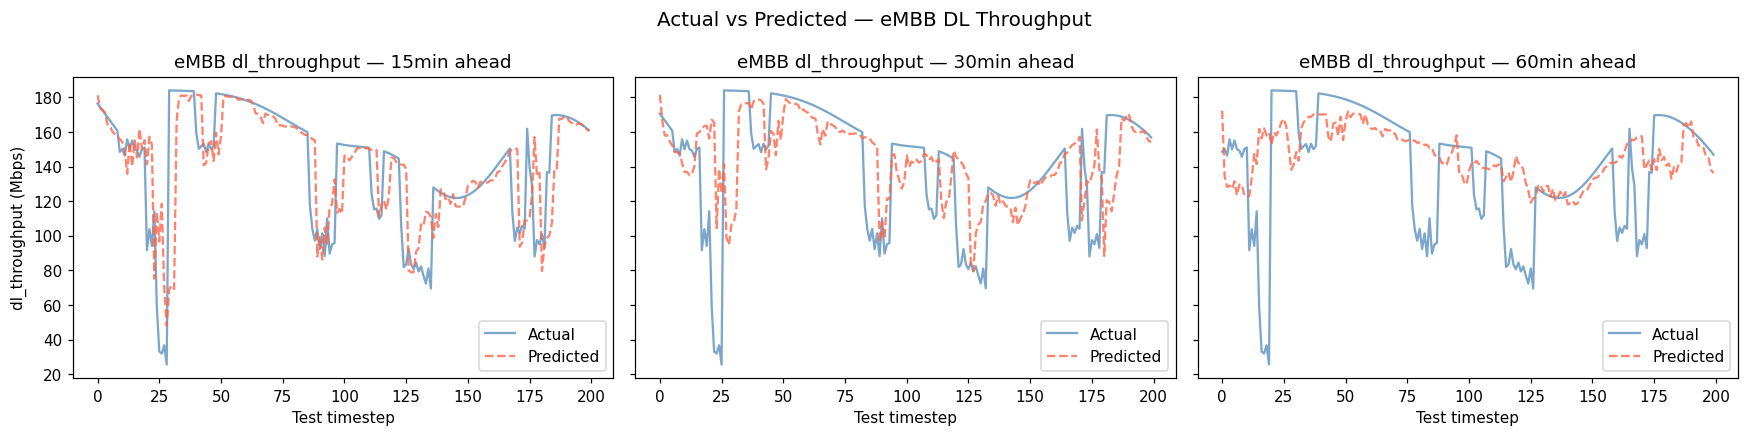

In [4]:
stype = "eMBB"
kpi   = "dl_throughput"
n_show = 200

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (h_min, h_steps) in zip(axes, HORIZON_STEPS.items()):
    model = load_forecaster(stype, kpi, h_min, models_dir=Path("../models"))
    X_test, y_test = _prepare_fcst_X_y(test_splits[stype], kpi, h_steps)
    y_pred = model.predict(X_test)

    ax.plot(y_test.values[:n_show], label="Actual", alpha=0.7, color="steelblue")
    ax.plot(y_pred[:n_show], label="Predicted", alpha=0.8, linestyle="--", color="tomato")
    ax.set_title(f"{stype} {kpi} — {h_min}min ahead")
    ax.set_xlabel("Test timestep")
    ax.legend()

axes[0].set_ylabel("dl_throughput (Mbps)")
plt.suptitle("Actual vs Predicted — eMBB DL Throughput", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Residual distributions — eMBB latency

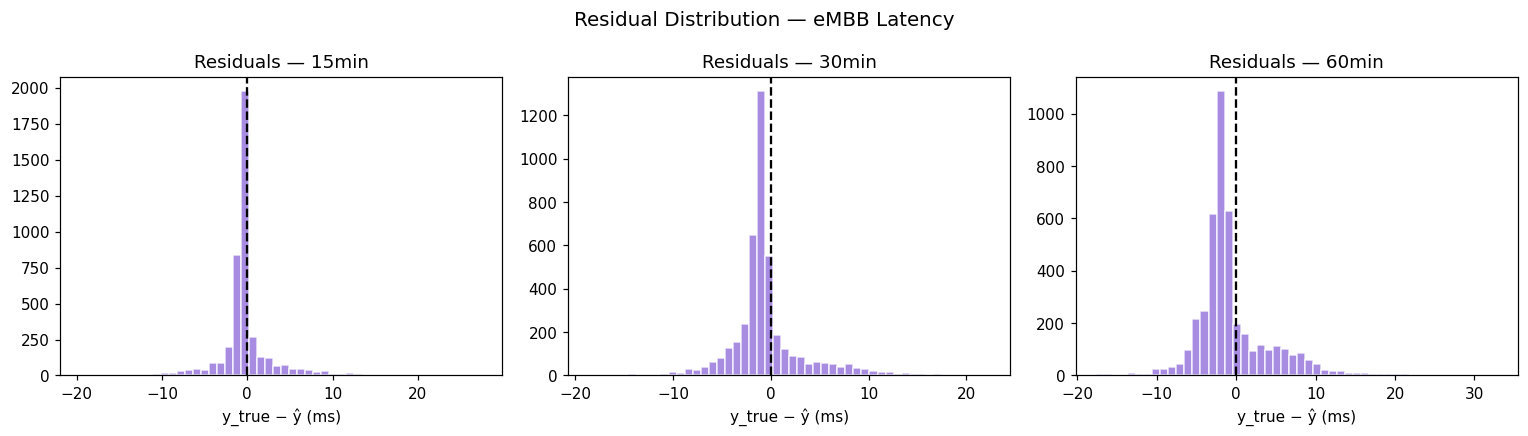

In [5]:
stype = "eMBB"
kpi   = "latency"

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (h_min, h_steps) in zip(axes, HORIZON_STEPS.items()):
    model = load_forecaster(stype, kpi, h_min, models_dir=Path("../models"))
    X_test, y_test = _prepare_fcst_X_y(test_splits[stype], kpi, h_steps)
    residuals = y_test.values - model.predict(X_test)
    ax.hist(residuals, bins=50, color="mediumpurple", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(f"Residuals — {h_min}min")
    ax.set_xlabel("y_true − ŷ (ms)")

plt.suptitle("Residual Distribution — eMBB Latency", fontsize=13)
plt.tight_layout()
plt.show()
